# Experimental Research Log: Foodlytics AI Strategic Focus
This notebook documents experiments conducted to test the Foodlytics app's strategic focus feature. Users will be able to select one of the following Strategic Focus' from the drop down to change the response style of the LLM: 
- Market Saturation
- Pricing Strategy
- Cuisine Analysis

## Experiment 1: Using the Same Prompt & Changing the Strategic Focus 

### 1. Hypothesis
The LLM should talk about density/opportunity when Market Saturation is selected, price vs. rating when Pricing Strategy is selected and underprepresented cuisines when Cuisine Analysis is selected.

### 2. Input Query
* "Should I open a pizza restaurant in Vancouver?"

### 3. Observed Behaviour 
Across all dropdown selections, the LLM produced generic feedback rather than focus-specific insights. The following response was received: 

"I can provide insights into the existing pizza restaurant landscape in Vancouver, which can help inform your decision. I’ll check the data for average ratings, number of reviews, and price ranges for pizza restaurants in that city."

### 4. Conclusion
The model did not adapt its response to the selected strategic focus, failing to provide the specific insights as hypothesized.

## Experiment 2: Updating the Prompt with Specialized Instructions 

### Changes
The base prompt was updated to instruct the LLM to act as a strategic consultant and structure its responses based on the dataset. The following instructions were added:

```You should always: 1) Use the dataset to support your reasoning 2) Explain insights clearly 3) Give a final recommendation```

The prompts for each dropdown were also updated to provide more specific guidance and force the LLM to reference particular dataset columns. For example, for the Cuisine Analysis, the following instructions were included:

```1) Count restaurants by cuisine type (category_2 column) within cities 2) Identify cuisines with few restaurants. 3) In your response, mention underrepresented cuisines and cities where they are missing```

### 1. Hypothesis
The LLM should have structured responses and provide a reccommendation that is specific to the dropdown selected. The LLM should talk about density/opportunity when Market Saturation is selected, price vs. rating when Pricing Strategy is selected and underprepresented cuisines when Cuisine Analysis is selected.

### 2. Input Query
* "Should I open a pizza restaurant in Vancouver?"

### 3. Observed Behaviour 

The LLM now responds differently depending on the dropdown selection:

For Pricing Strategy, it successfully counts pizza restaurants by price category, compares average ratings, and recommends a competitive market focus (e.g., mid-range offerings).

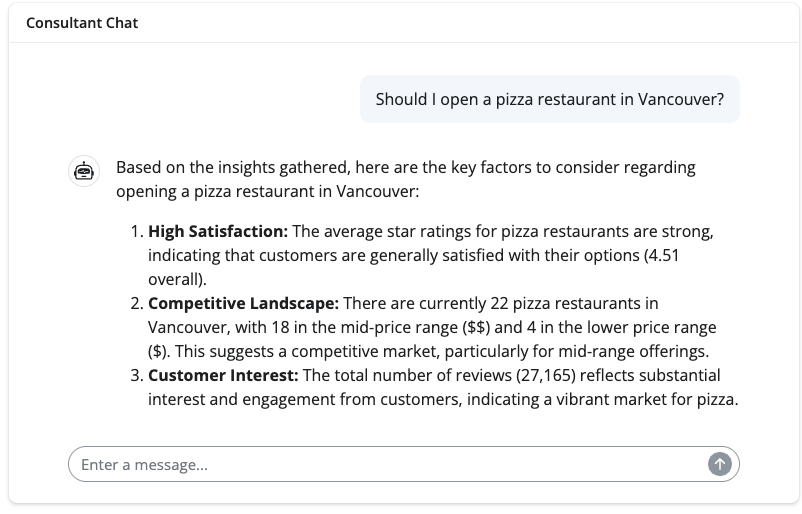

For Cuisine Analysis, it counts pizza restaurants in Vancouver and highlights that the market is already established with 22 pizza restaurants. 

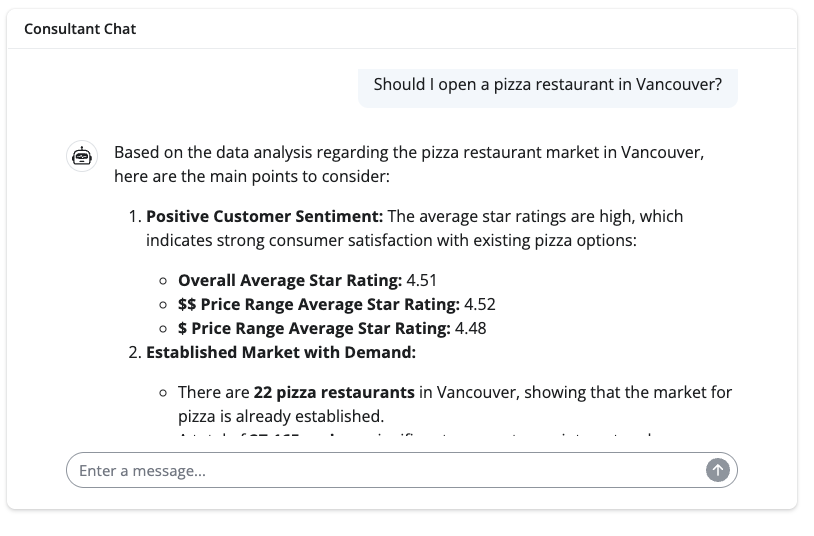

However, since the prompt focused specifically on Vancouver, the LLM did not mention underserved opportunities in other cities.

The underlying dataset is also reflected in the response, as an example: 
```SELECT city, AVG(star) as avg_rating, price_range FROM foodlytics WHERE category_2 = 'Pizza' GROUP BY city, price_range ORDER BY avg_rating ASC```

### 4. Conclusion
The experiment was successful as the LLM provided different responses depending on the selected strategic focus. Although additional context or a more generic prompt may be needed if responses should consider multiple cities beyond Vancouver.